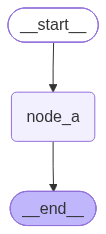

============================== -> username_interrupted_res <- ==============================
{'__interrupt__': [Interrupt(value='请输入您的姓名', id='7748574feba4631e5159e41123a747a3')]}
============================== -> username_interrupted_his <- ==============================
[StateSnapshot(values={}, next=('node_a',), config={'configurable': {'thread_id': '123', 'checkpoint_ns': '', 'checkpoint_id': '1f1b4345-f587-6194-8000-e29e88e67259'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-09-19T14:14:05.612678+00:00', parent_config={'configurable': {'thread_id': '123', 'checkpoint_ns': '', 'checkpoint_id': '1f1b4345-f584-60b7-bfff-ba54ec54b5a1'}}, tasks=(PregelTask(id='c62d5cb9-aa9f-f64c-6249-cd294287fa74', name='node_a', path=('__pregel_pull', 'node_a'), error=None, interrupts=(Interrupt(value='请输入您的姓名', id='7748574feba4631e5159e41123a747a3'),), state=None, result=None),), interrupts=(Interrupt(value='请输入您的姓名', id='7748574feba4631e5159e41123a747a3'),)), StateSnapsh

In [1]:
from typing import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.types import Command, interrupt
from langgraph.checkpoint.memory import InMemorySaver

class OverAllState(TypedDict):
    username: str
    age: int

def node_a(state: OverAllState) -> OverAllState:
    username = interrupt("请输入您的姓名")
    age = interrupt("请输入您的年龄")
    return {
        "username": username,
        "age": age
    }

builder = StateGraph(state_schema=OverAllState)
builder.add_node("node_a", node_a)
builder.add_edge(START, "node_a")
builder.add_edge("node_a", END)

checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

from IPython.display import display
display(graph)


config = {"configurable": {"thread_id": "123"}}
username_interrupted_res = graph.invoke({}, config=config)
print('=' * 30, '-> username_interrupted_res <-', '=' * 30)
print(username_interrupted_res)
username_interrupted_his = list(graph.get_state_history(config=config))
print('=' * 30, '-> username_interrupted_his <-', '=' * 30)
print(username_interrupted_his)

age_interrupted_res = graph.invoke(Command(resume="小黄"), config=config)
print('=' * 30, '-> age_interrupted_res <-', '=' * 30)
print(age_interrupted_res)
age_interrupted_his = list(graph.get_state_history(config=config))
print('=' * 30, '-> age_interrupted_his <-', '=' * 30)
print(age_interrupted_his)

resumed_res = graph.invoke(Command(resume=123), config=config)
print('=' * 30, '-> resumed_res <-', '=' * 30)
print(resumed_res)
resumed_his = list(graph.get_state_history(config=config))
print('=' * 30, '-> resumed_his <-', '=' * 30)
print(resumed_his)

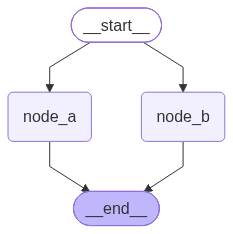

============================== -> interrupt_res <- ==============================
{'__interrupt__': [Interrupt(value='请输入您的姓名', id='2112908607d2b70d0406f8c90d974be6'), Interrupt(value='请输入您的年龄', id='89933455ff03358f096280c1bcc66dd0')]}
{'username': 'fyk', 'age': 23}


[StateSnapshot(values={'username': 'fyk', 'age': 23}, next=(), config={'configurable': {'thread_id': '123', 'checkpoint_ns': '', 'checkpoint_id': '1f1b3edd-071d-6164-8001-20db8ac1957b'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-09-19T05:49:01.093718+00:00', parent_config={'configurable': {'thread_id': '123', 'checkpoint_ns': '', 'checkpoint_id': '1f1b3edc-c9f2-63bb-8000-490dcbb1d622'}}, tasks=(), interrupts=()),
 StateSnapshot(values={}, next=('node_a', 'node_b'), config={'configurable': {'thread_id': '123', 'checkpoint_ns': '', 'checkpoint_id': '1f1b3edc-c9f2-63bb-8000-490dcbb1d622'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-09-19T05:48:54.679852+00:00', parent_config={'configurable': {'thread_id': '123', 'checkpoint_ns': '', 'checkpoint_id': '1f1b3edc-c9f0-6ff0-bfff-c94314417521'}}, tasks=(PregelTask(id='7179641c-46d6-146f-3396-6e059ccc7cfa', name='node_a', path=('__pregel_pull', 'node_a'), error=None, interrupts=(Interr

In [3]:
from typing import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.types import Command, interrupt
from langgraph.checkpoint.memory import InMemorySaver

class OverAllState(TypedDict):
    username: str
    age: int

def node_a(state: OverAllState) -> OverAllState:
    username = interrupt("请输入您的姓名")
    return {
        "username": username
    }

def node_b(state: OverAllState) -> OverAllState:
    age = interrupt("请输入您的年龄")
    return {
        "age": age
    }

builder = StateGraph(state_schema=OverAllState)
builder.add_node("node_a", node_a)
builder.add_node("node_b", node_b)
builder.add_edge(START, "node_a")
builder.add_edge(START, "node_b")
builder.add_edge("node_a", END)
builder.add_edge("node_b", END)

checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

from IPython.display import display
display(graph)

config = {"configurable": {"thread_id": "123"}}
interrupted_res = graph.invoke({}, config=config)
print('=' * 30, '-> interrupt_res <-', '=' * 30)
print(interrupted_res)

list(graph.get_state_history(config=config))

# 6. 恢复执行
resume_map = {}
for i in interrupted_res['__interrupt__']:
    user_input = input(f"{i.value}:")
    if "年龄" in i.value:
        resume_map[i.id] = int(user_input)
    else:
        resume_map[i.id] = user_input

resumed_res = graph.invoke(Command(resume=resume_map),config=config)
print(resumed_res)

list(graph.get_state_history(config=config))

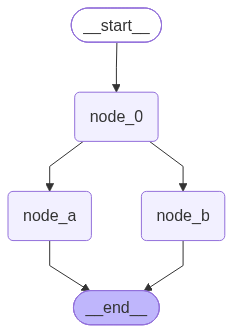

============================== -> interrupt_res <- ==============================
{'test': '本次已经保存成功test字段', 'age': 12, '__interrupt__': [Interrupt(value='请输入您的姓名', id='7cacf7a195ece927e3eae8e4cdf9bbcf')]}


[StateSnapshot(values={'test': '本次已经保存成功test字段'}, next=('node_a', 'node_b'), config={'configurable': {'thread_id': '123', 'checkpoint_ns': '', 'checkpoint_id': '1f1b3ef2-c1b8-620f-8001-692053d68480'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-09-19T05:58:44.375195+00:00', parent_config={'configurable': {'thread_id': '123', 'checkpoint_ns': '', 'checkpoint_id': '1f1b3ef2-c1b5-6abe-8000-bd78558ae6cb'}}, tasks=(PregelTask(id='0ec835d4-8456-7462-8f3d-16fb53d81d62', name='node_a', path=('__pregel_pull', 'node_a'), error=None, interrupts=(Interrupt(value='请输入您的姓名', id='7cacf7a195ece927e3eae8e4cdf9bbcf'),), state=None, result=None), PregelTask(id='f7ae1a4e-9416-3b5a-70c9-628d9c5bfb67', name='node_b', path=('__pregel_pull', 'node_b'), error=None, interrupts=(), state=None, result={'age': 12})), interrupts=(Interrupt(value='请输入您的姓名', id='7cacf7a195ece927e3eae8e4cdf9bbcf'),)),
 StateSnapshot(values={}, next=('node_0',), config={'configurable': {'thread_id': '123', 

In [ ]:
'''
因为这个并行执行步尚未全部完成，还没有生成包含两个节点最终更新的新完整检查点。
但 node_b 的结果已经单独保存为与当前检查点关联的任务写入，通常称为 pending writes（待合并写入）
'''


from typing import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.types import Command, interrupt
from langgraph.checkpoint.memory import InMemorySaver

class OverAllState(TypedDict):
    test: str
    username: str
    age: int

def node_0(state: OverAllState) -> OverAllState:
    return {
        "test": "本次已经保存成功test字段"
    }

def node_a(state: OverAllState) -> OverAllState:
    username = interrupt("请输入您的姓名")
    return {
        "username": username
    }

def node_b(state: OverAllState) -> OverAllState:
    age = 12
    return {
        "age": age
    }

builder = StateGraph(state_schema=OverAllState)
builder.add_node("node_0", node_0)
builder.add_node("node_a", node_a)
builder.add_node("node_b", node_b)
builder.add_edge(START, "node_0")
builder.add_edge("node_0", "node_a")
builder.add_edge("node_0", "node_b")
builder.add_edge("node_a", END)
builder.add_edge("node_b", END)

checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

from IPython.display import display
display(graph)

config = {"configurable": {"thread_id": "123"}}
interrupted_res = graph.invoke({}, config=config)
print('=' * 30, '-> interrupt_res <-', '=' * 30)
print(interrupted_res)

list(graph.get_state_history(config=config))





In [ ]:
# 四大皆空洒进来开卷考试垃圾打蜡卡久啊溜达鸡